# Exploratory Data Analysis & Feature Engineering
## SME Financial Health Analyser · ASX Dataset

**Goals for this notebook:**
1. Understand the shape, coverage and distribution of our financial ratio dataset
2. Identify which ratios vary most across sectors and tickers
3. Detect multicollinearity between features (informs model feature selection)
4. Engineer a labelled `financial_health` target variable for supervised learning
5. Export a model-ready feature matrix to `data/processed/features.parquet`

---
*Data source: `data/processed/ratios_clean.parquet`*


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Data Loading

In [2]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.4,
    "grid.linestyle":    "--",
    "font.family":       "sans-serif",
    "figure.dpi":        120,
})
PALETTE = sns.color_palette("tab10", 7)

# ── Load data ──────────────────────────────────────────────────────────────
DATA_PATH = Path("/content/drive/MyDrive/data/processed/ratios_clean.parquet")
df = pd.read_parquet(DATA_PATH)
df = df.reset_index()
df["quarter"] = pd.to_datetime(df["quarter"])

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Tickers : {df['ticker'].nunique()}")
print(f"Sectors : {df['sector'].nunique()} → {sorted(df['sector'].unique())}")
print(f"Date range: {df['quarter'].min().date()} → {df['quarter'].max().date()}")
print(f"Quarters per ticker (avg): {df.groupby('ticker').size().mean():.1f}")


Loaded: 21 rows × 27 columns
Tickers : 3
Sectors : 2 → ['Communication Services', 'Healthcare']
Date range: 2024-09-30 → 2026-03-31
Quarters per ticker (avg): 7.0


## 2. Data Coverage & Missing Values

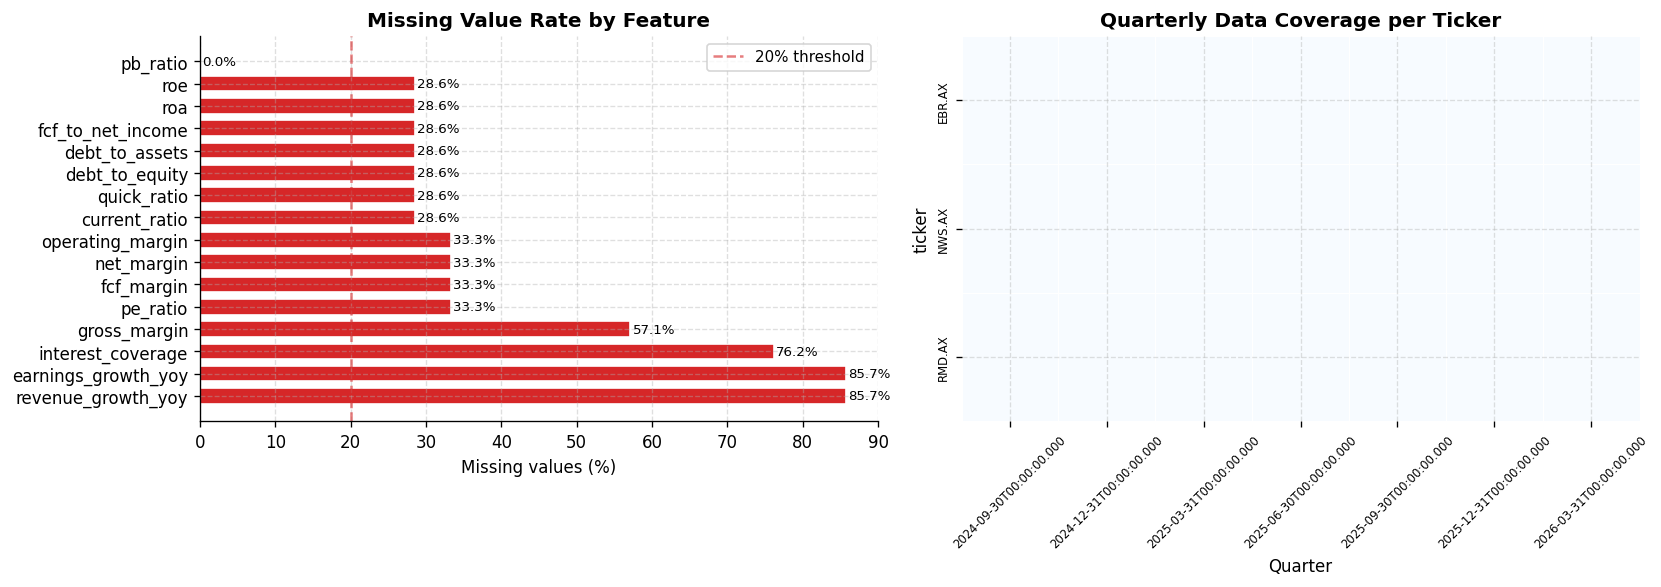


Features with >20% missing: 15


In [3]:
RATIO_COLS = [
    "current_ratio","quick_ratio","debt_to_equity","debt_to_assets",
    "interest_coverage","gross_margin","operating_margin","net_margin",
    "roe","roa","fcf_margin","fcf_to_net_income",
    "revenue_growth_yoy","earnings_growth_yoy","pe_ratio","pb_ratio",
]

# Missing value heatmap
missing = df[RATIO_COLS].isna().mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of missing %
axes[0].barh(missing.index, missing.values,
             color=["#d62728" if v > 20 else "#2196F3" for v in missing.values],
             edgecolor="white", height=0.7)
axes[0].axvline(20, color="#d62728", linestyle="--", alpha=0.6, label="20% threshold")
axes[0].set_xlabel("Missing values (%)")
axes[0].set_title("Missing Value Rate by Feature", fontweight="bold")
axes[0].legend(fontsize=9)
for i, v in enumerate(missing.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)

# Coverage heatmap per ticker
pivot_missing = df.pivot_table(index="ticker", columns="quarter",
                                values="operating_margin", aggfunc="count")
pivot_missing = pivot_missing.notna().astype(int)
sns.heatmap(pivot_missing, ax=axes[1], cmap="Blues", cbar=False,
            linewidths=0.3, linecolor="white")
axes[1].set_title("Quarterly Data Coverage per Ticker", fontweight="bold")
axes[1].set_xlabel("Quarter")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/data/processed/fig_missing_values.png", bbox_inches="tight")
plt.show()
print(f"\nFeatures with >20% missing: {(missing > 20).sum()}")


## 3. Distribution of Key Financial Ratios

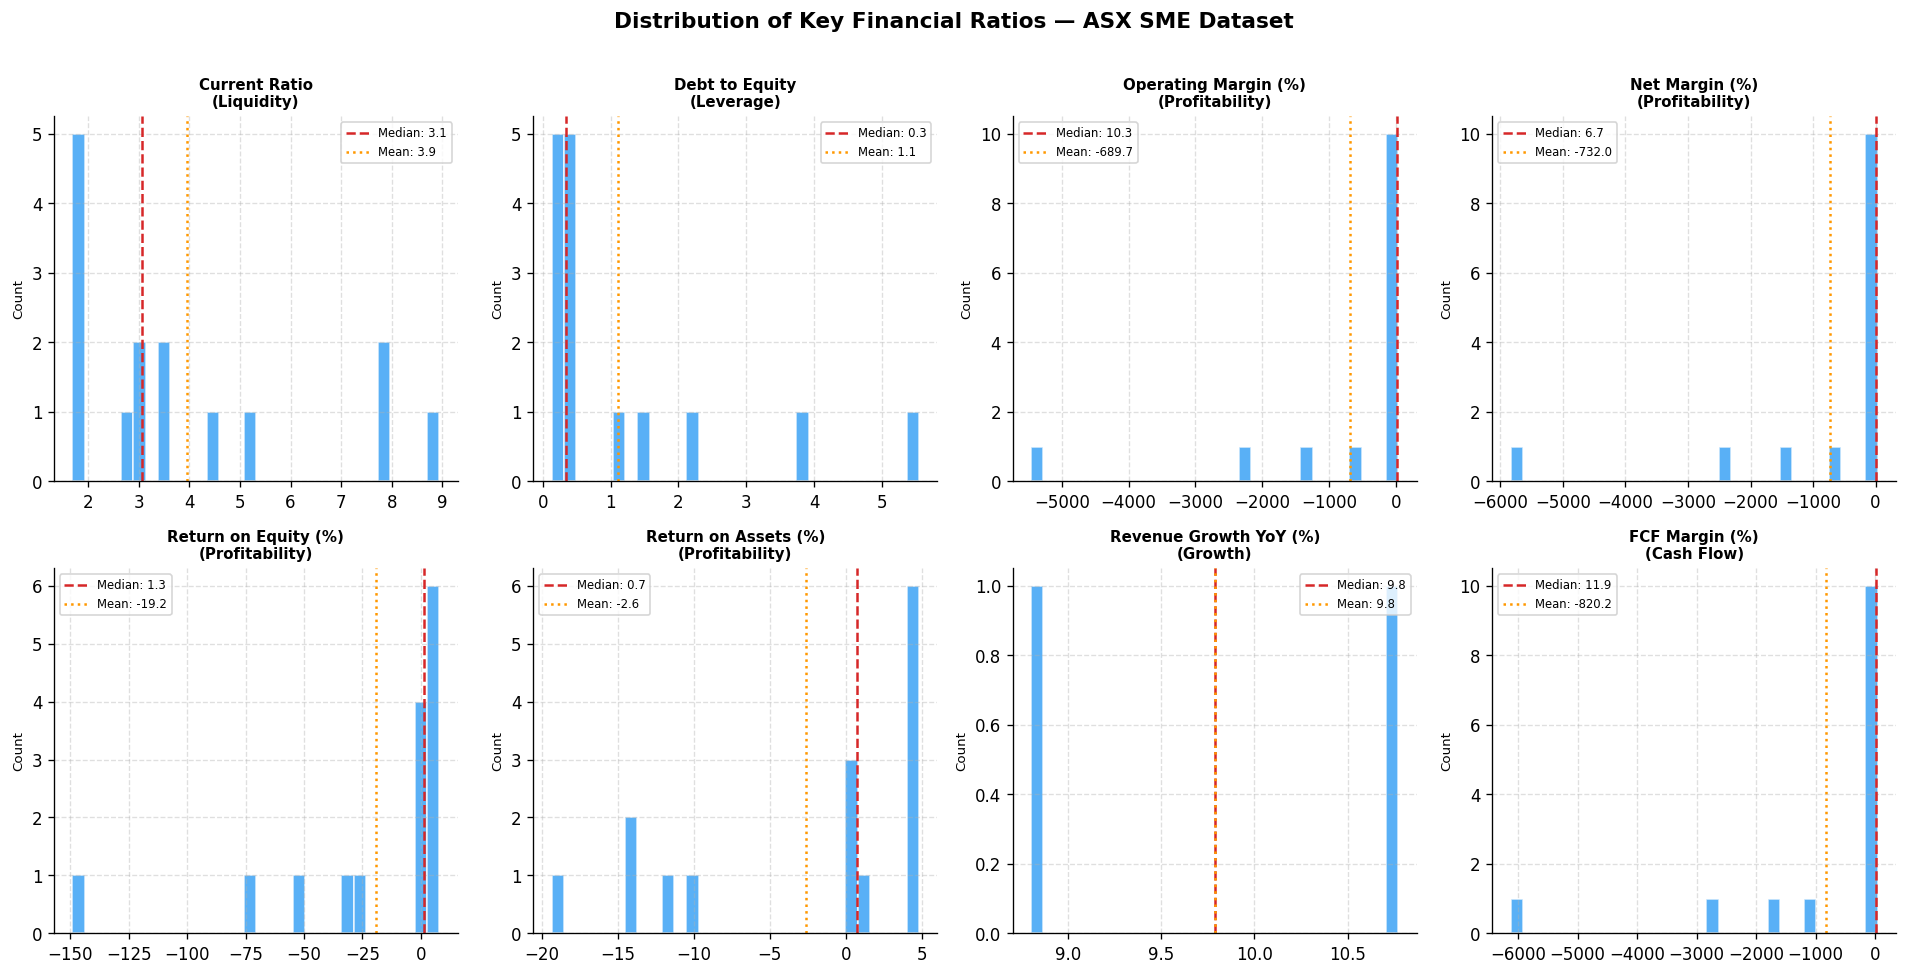

In [6]:
PLOT_RATIOS = [
    ("current_ratio",       "Current Ratio",         "Liquidity"),
    ("debt_to_equity",      "Debt to Equity",         "Leverage"),
    ("operating_margin",    "Operating Margin (%)",   "Profitability"),
    ("net_margin",          "Net Margin (%)",         "Profitability"),
    ("roe",                 "Return on Equity (%)",   "Profitability"),
    ("roa",                 "Return on Assets (%)",   "Profitability"),
    ("revenue_growth_yoy",  "Revenue Growth YoY (%)", "Growth"),
    ("fcf_margin",          "FCF Margin (%)",         "Cash Flow"),
]

# Clean inf and NaN before plotting (real ASX data can have inf from zero-division)
for col, _, _ in PLOT_RATIOS:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, (col, label, category) in zip(axes, PLOT_RATIOS):
    data = df[col].dropna()
    # clip extreme outliers for display
    lo, hi = data.quantile(0.02), data.quantile(0.98)
    data_clipped = data.clip(lo, hi)

    ax.hist(data_clipped, bins=30, color="#2196F3", alpha=0.75, edgecolor="white")
    ax.axvline(data_clipped.median(), color="#d62728", linestyle="--",
               linewidth=1.5, label=f"Median: {data_clipped.median():.1f}")
    ax.axvline(data_clipped.mean(),   color="#FF9800", linestyle=":",
               linewidth=1.5, label=f"Mean: {data_clipped.mean():.1f}")
    ax.set_title(f"{label}\n({category})", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
    ax.set_ylabel("Count", fontsize=8)

plt.suptitle("Distribution of Key Financial Ratios — ASX SME Dataset",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/data/processed/fig_distributions.png", bbox_inches="tight")
plt.show()

## 4. Sector Comparison — Which Sectors are Healthiest?

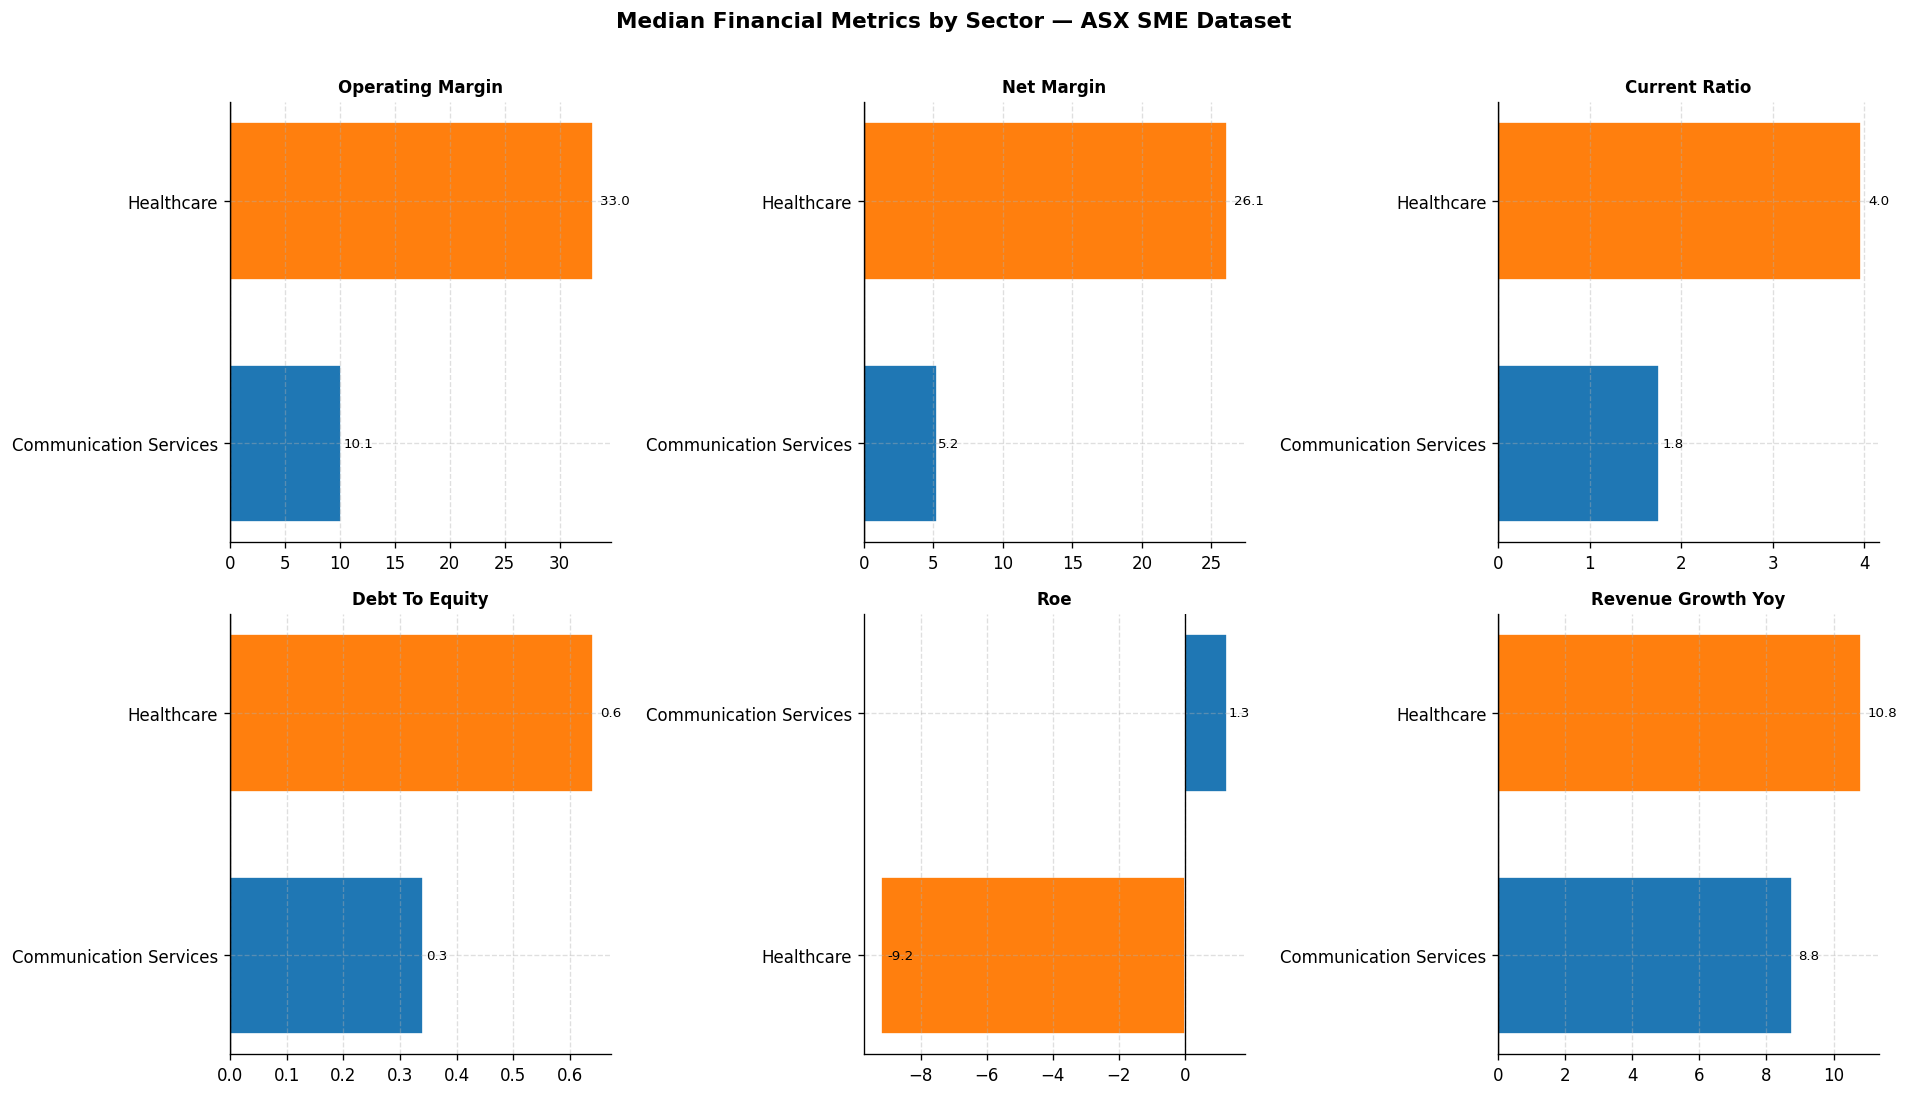


Full sector medians:
                        operating_margin  net_margin  current_ratio  debt_to_equity   roe  revenue_growth_yoy
sector                                                                                                       
Communication Services             10.11        5.22           1.76            0.34  1.29                8.76
Healthcare                         33.00       26.10           3.96            0.64 -9.19               10.81


In [7]:
SECTOR_METRICS = ["operating_margin","net_margin","current_ratio",
                  "debt_to_equity","roe","revenue_growth_yoy"]

sector_avg = df.groupby("sector")[SECTOR_METRICS].median().round(2)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = dict(zip(sorted(df["sector"].unique()), PALETTE))

for ax, col in zip(axes, SECTOR_METRICS):
    vals   = sector_avg[col].sort_values(ascending=True)
    clrs   = [colors[s] for s in vals.index]
    bars   = ax.barh(vals.index, vals.values, color=clrs, edgecolor="white", height=0.65)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=10)
    ax.axvline(0, color="black", linewidth=0.8)
    for bar, val in zip(bars, vals.values):
        ax.text(val + (abs(val) * 0.02), bar.get_y() + bar.get_height()/2,
                f"{val:.1f}", va="center", fontsize=8)

plt.suptitle("Median Financial Metrics by Sector — ASX SME Dataset",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/data/processed/fig_sector_comparison.png", bbox_inches="tight")
plt.show()

print("\nFull sector medians:")
print(sector_avg.to_string())


## 5. Correlation Analysis & Multicollinearity

Understanding correlations between features is critical before modelling:
- **High correlation (>0.85)** between two features = one is redundant → drop it
- **Correlation with target** = predictive power signal


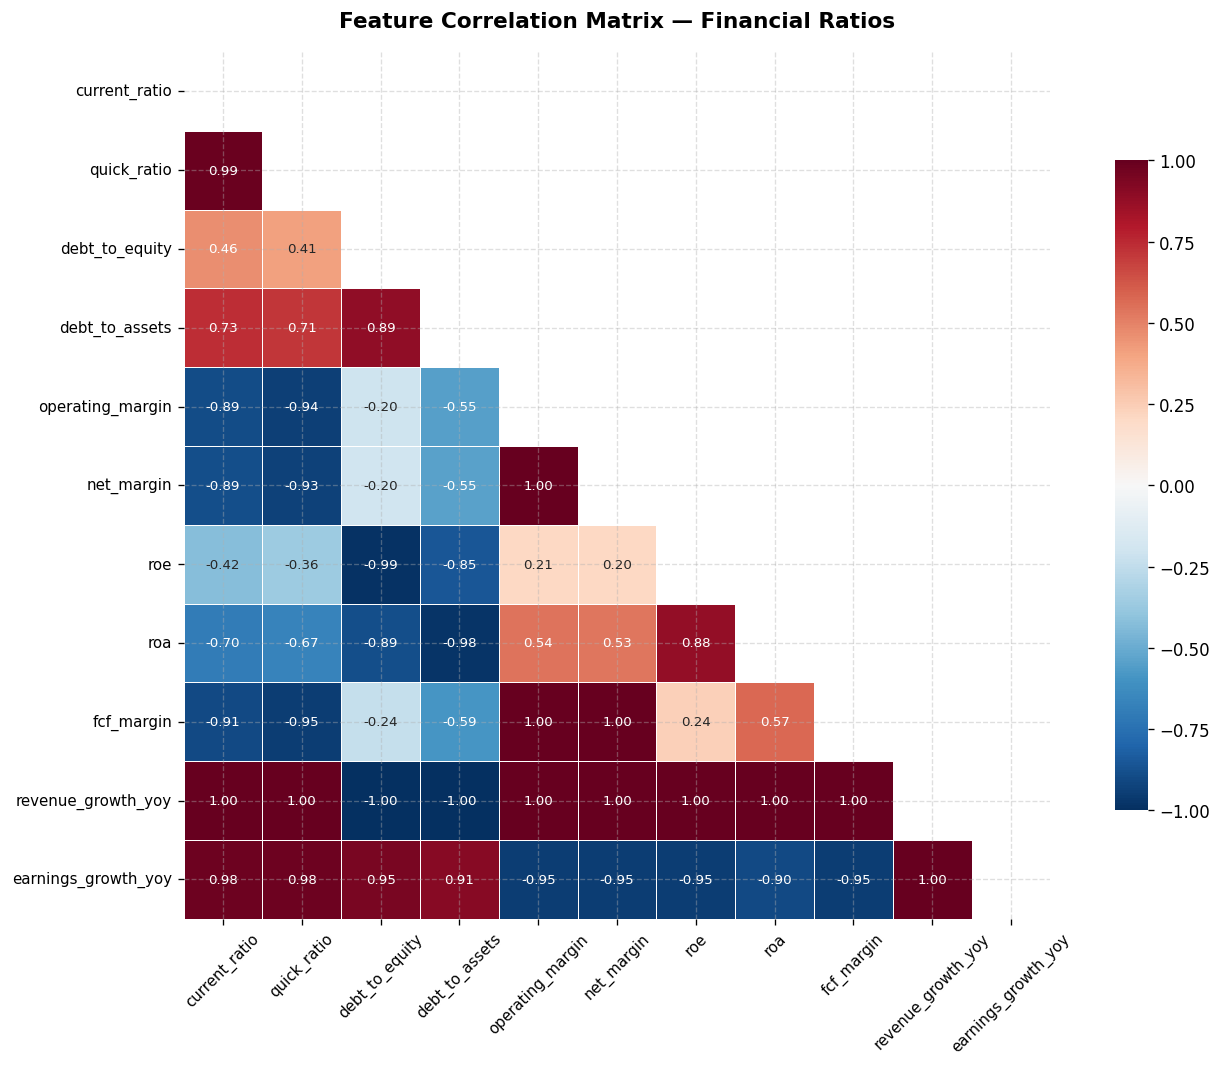


High-correlation pairs (|r| > 0.75) — candidates for dropping:
  current_ratio                  ↔ revenue_growth_yoy              r = +1.000
  quick_ratio                    ↔ revenue_growth_yoy              r = +1.000
  debt_to_equity                 ↔ revenue_growth_yoy              r = -1.000
  debt_to_assets                 ↔ revenue_growth_yoy              r = -1.000
  operating_margin               ↔ net_margin                      r = +1.000
  operating_margin               ↔ revenue_growth_yoy              r = +1.000
  net_margin                     ↔ revenue_growth_yoy              r = +1.000
  roe                            ↔ revenue_growth_yoy              r = +1.000
  roa                            ↔ revenue_growth_yoy              r = +1.000
  fcf_margin                     ↔ revenue_growth_yoy              r = +1.000
  revenue_growth_yoy             ↔ earnings_growth_yoy             r = +1.000
  operating_margin               ↔ fcf_margin                      r = +0.999


In [8]:
corr_cols = [
    "current_ratio","quick_ratio","debt_to_equity","debt_to_assets",
    "operating_margin","net_margin","roe","roa",
    "fcf_margin","revenue_growth_yoy","earnings_growth_yoy",
]

corr_matrix = df[corr_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.75},
)
ax.set_title("Feature Correlation Matrix — Financial Ratios",
             fontsize=13, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/data/processed/fig_correlation.png", bbox_inches="tight")
plt.show()

# Flag high-correlation pairs
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.75:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

print(f"\nHigh-correlation pairs (|r| > 0.75) — candidates for dropping:")
for a, b, v in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f"  {a:30s} ↔ {b:30s}  r = {v:+.3f}")


## 6. Time Trends — How Have Metrics Evolved?

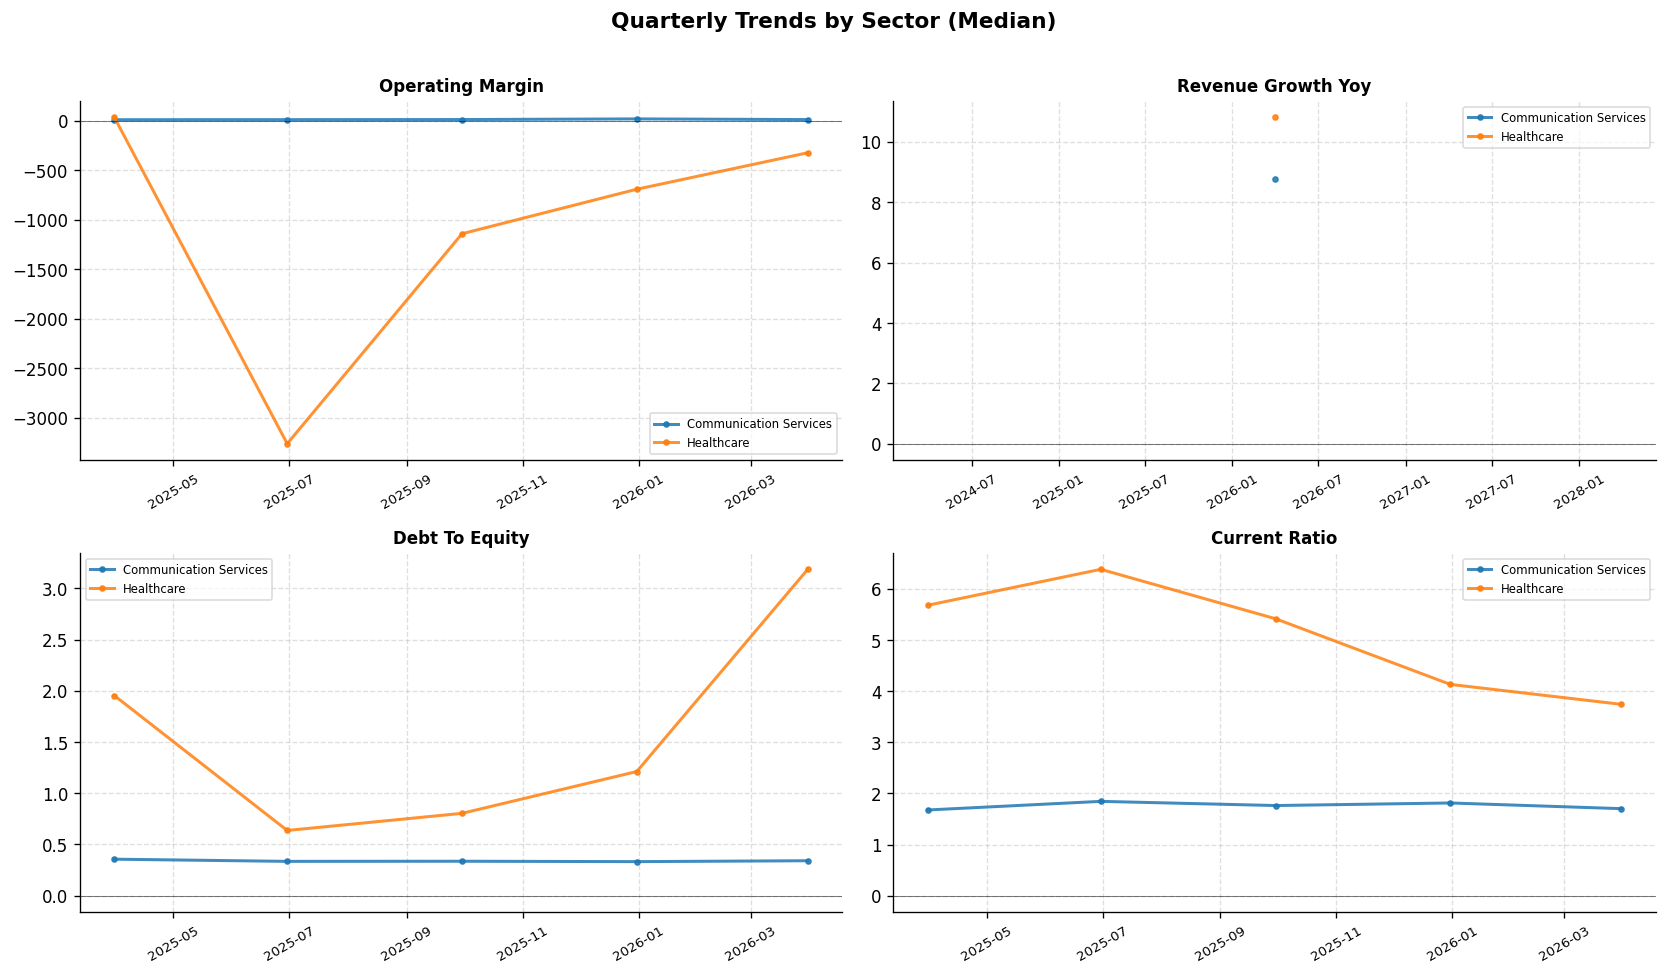

In [9]:
trend_metrics = ["operating_margin","revenue_growth_yoy","debt_to_equity","current_ratio"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, metric in zip(axes, trend_metrics):
    for sector, grp in df.groupby("sector"):
        quarterly = grp.groupby("quarter")[metric].median()
        ax.plot(quarterly.index, quarterly.values,
                label=sector, color=colors[sector],
                linewidth=1.8, marker="o", markersize=3, alpha=0.85)
    ax.set_title(metric.replace("_", " ").title(), fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.legend(fontsize=7, loc="best", framealpha=0.7)
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.5)

plt.suptitle("Quarterly Trends by Sector (Median)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/data/processed/fig_time_trends.png", bbox_inches="tight")
plt.show()


## 7. Outlier Detection

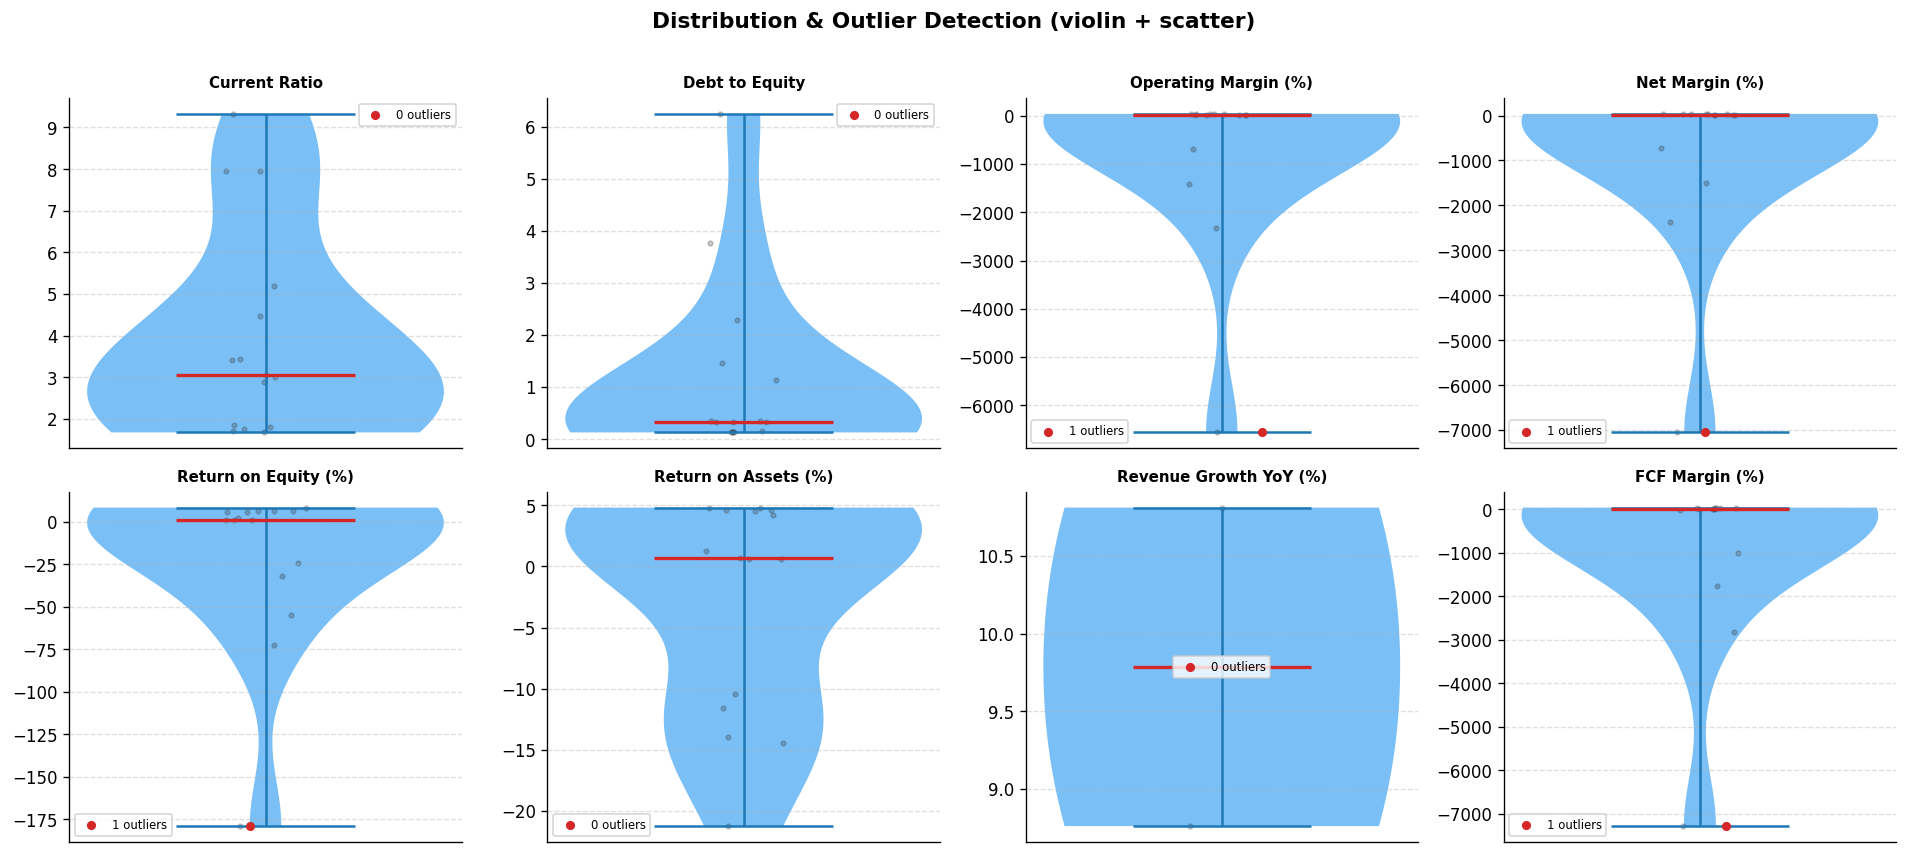

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, (col, label, _) in zip(axes, PLOT_RATIOS):
    data = df[col].dropna()
    parts = ax.violinplot(data, positions=[0], showmedians=True,
                          showextrema=True, widths=0.7)
    for pc in parts["bodies"]:
        pc.set_facecolor("#2196F3")
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("#d62728")
    parts["cmedians"].set_linewidth(2)

    # Overlay actual points (jittered)
    jitter = np.random.uniform(-0.08, 0.08, len(data))
    ax.scatter(jitter, data, alpha=0.25, s=8, color="#333333")

    # Highlight outliers (>3 std)
    mean, std = data.mean(), data.std()
    outliers = data[np.abs(data - mean) > 3 * std]
    ax.scatter(np.random.uniform(-0.08, 0.08, len(outliers)),
               outliers, color="#d62728", s=20, zorder=5, label=f"{len(outliers)} outliers")

    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_xticks([])
    ax.legend(fontsize=7)

plt.suptitle("Distribution & Outlier Detection (violin + scatter)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/data/processed/fig_outliers.png", bbox_inches="tight")
plt.show()


## 8. Feature Engineering

We engineer a composite **Financial Health Score** (0–100) as our target label
for supervised learning in Week 4. The score combines:

| Component | Weight | Rationale |
|---|---|---|
| Profitability (operating margin, net margin, ROE) | 30% | Core business efficiency |
| Liquidity (current ratio) | 20% | Ability to meet short-term obligations |
| Leverage (debt-to-equity — lower is better) | 20% | Long-term solvency risk |
| Growth (revenue YoY) | 15% | Forward momentum |
| Cash flow quality (FCF margin) | 15% | Earnings quality |

Companies scoring **< 35** are labelled **"At Risk"**, **35–65** as **"Stable"**, **> 65** as **"Healthy"**.


In [11]:
# Replace inf with NaN before feature engineering
for col in ["operating_margin","net_margin","roe","current_ratio",
            "debt_to_equity","revenue_growth_yoy","fcf_margin",
            "roa","gross_margin","interest_coverage","fcf_to_net_income",
            "revenue_growth_yoy","earnings_growth_yoy"]:
    if col in df.columns:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
feat = df.copy()

def minmax_scale(series: pd.Series) -> pd.Series:
    """Scale a series to [0, 100], clipping at 1st/99th percentile."""
    lo, hi = series.quantile(0.01), series.quantile(0.99)
    clipped = series.clip(lo, hi)
    return (clipped - lo) / (hi - lo + 1e-9) * 100

def inverse_scale(series: pd.Series) -> pd.Series:
    """Scale where LOWER is better (e.g. debt_to_equity) → invert."""
    return 100 - minmax_scale(series)

# ── Component scores ───────────────────────────────────────────────────────

feat["score_profitability"] = (
    minmax_scale(feat["operating_margin"]) * 0.4 +
    minmax_scale(feat["net_margin"])       * 0.35 +
    minmax_scale(feat["roe"])              * 0.25
)

feat["score_liquidity"] = minmax_scale(feat["current_ratio"])

feat["score_leverage"]  = inverse_scale(feat["debt_to_equity"])

feat["score_growth"]    = minmax_scale(feat["revenue_growth_yoy"])

feat["score_cashflow"]  = minmax_scale(feat["fcf_margin"])

# ── Composite score ────────────────────────────────────────────────────────
feat["financial_health_score"] = (
    feat["score_profitability"] * 0.30 +
    feat["score_liquidity"]     * 0.20 +
    feat["score_leverage"]      * 0.20 +
    feat["score_growth"]        * 0.15 +
    feat["score_cashflow"]      * 0.15
).round(2)

# ── Labels ─────────────────────────────────────────────────────────────────
def label_health(score):
    if score < 35:  return "At Risk"
    if score < 65:  return "Stable"
    return "Healthy"

feat["health_label"] = feat["financial_health_score"].apply(label_health)

# ── Summary ────────────────────────────────────────────────────────────────
print("Financial Health Score distribution:")
print(feat["financial_health_score"].describe().round(2))
print()
print("Label counts:")
print(feat["health_label"].value_counts())
print()
print("Score by sector (median):")
print(feat.groupby("sector")["financial_health_score"].median().sort_values(ascending=False).round(1))


Financial Health Score distribution:
count     2.00
mean     73.66
std      13.85
min      63.86
25%      68.76
50%      73.66
75%      78.55
max      83.45
Name: financial_health_score, dtype: float64

Label counts:
health_label
Healthy    20
Stable      1
Name: count, dtype: int64

Score by sector (median):
sector
Healthcare                83.4
Communication Services    63.9
Name: financial_health_score, dtype: float64


## 9. Financial Health Score — Distribution & Sector Breakdown

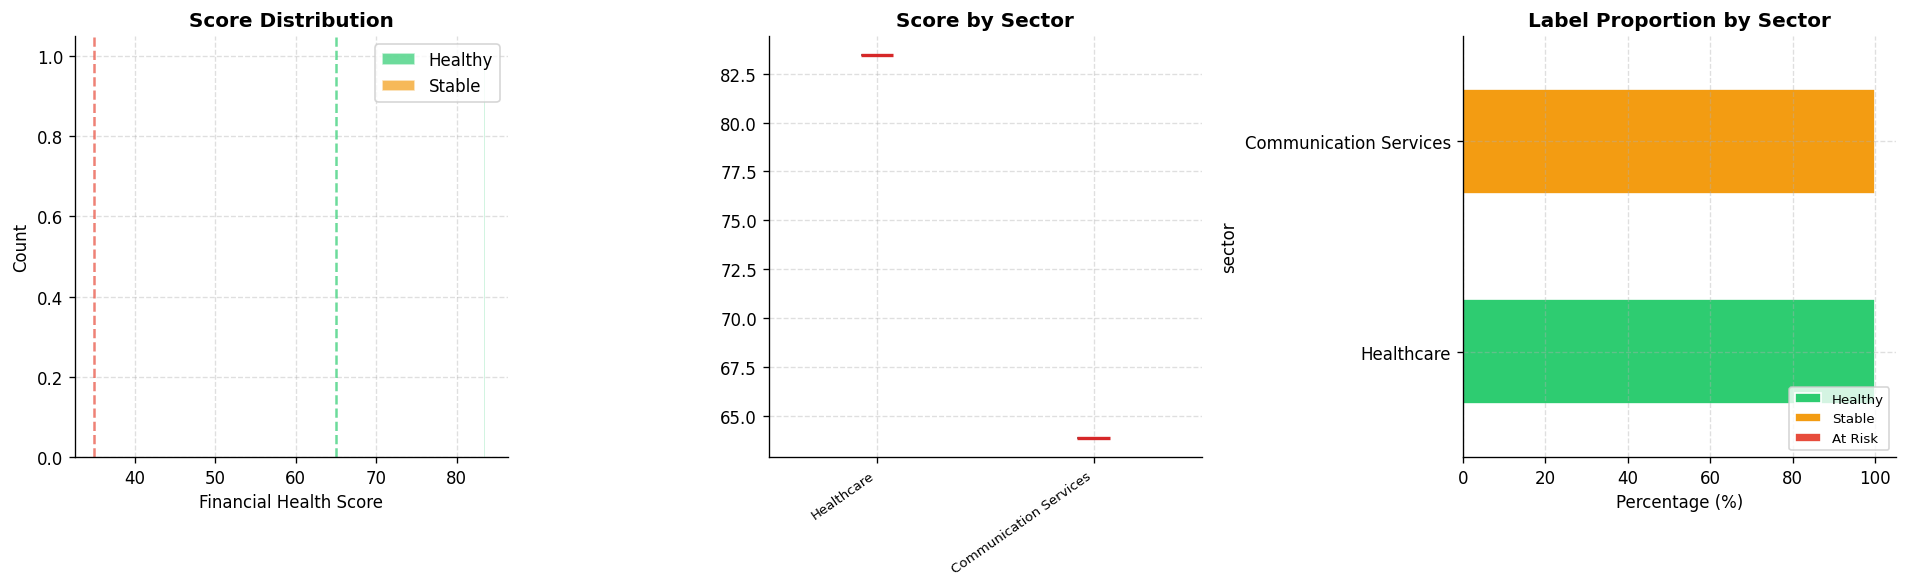

In [12]:
# Drop NaN health scores before plotting (propagated from inf in ratio columns)
feat_plot = feat.dropna(subset=["financial_health_score"]).copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

label_colors = {"Healthy": "#2ecc71", "Stable": "#f39c12", "At Risk": "#e74c3c"}

# Score histogram
for label, grp in feat_plot.groupby("health_label"):
    axes[0].hist(grp["financial_health_score"], bins=20, alpha=0.7,
                 label=label, color=label_colors[label], edgecolor="white")
axes[0].set_xlabel("Financial Health Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Score Distribution", fontweight="bold")
axes[0].legend()
axes[0].axvline(35, color="#e74c3c", linestyle="--", alpha=0.7)
axes[0].axvline(65, color="#2ecc71", linestyle="--", alpha=0.7)

# Score by sector (boxplot - fixed API)
sector_order = (feat_plot.groupby("sector")["financial_health_score"]
                .median().sort_values(ascending=False).index.tolist())
sector_data = [feat[feat["sector"] == s]["financial_health_score"].dropna().values
               for s in sector_order]
bp = axes[1].boxplot(sector_data, patch_artist=True, vert=True,
                     medianprops=dict(color="#d62728", linewidth=2))
for patch in bp["boxes"]:
    patch.set_facecolor("#2196F3")
    patch.set_alpha(0.6)
axes[1].set_xticks(range(1, len(sector_order) + 1))
axes[1].set_xticklabels(sector_order, rotation=35, ha="right", fontsize=8)
axes[1].set_title("Score by Sector", fontweight="bold")

# Label proportion by sector
label_counts = feat_plot.groupby(["sector", "health_label"]).size().unstack(fill_value=0)
label_pct = label_counts.div(label_counts.sum(axis=1), axis=0) * 100
label_pct = label_pct.reindex(sector_order)
for col in ["Healthy", "Stable", "At Risk"]:
    if col not in label_pct.columns:
        label_pct[col] = 0
label_pct[["Healthy", "Stable", "At Risk"]].plot(
    kind="barh", stacked=True, ax=axes[2],
    color=[label_colors[l] for l in ["Healthy", "Stable", "At Risk"]],
    edgecolor="white",
)
axes[2].set_title("Label Proportion by Sector", fontweight="bold")
axes[2].set_xlabel("Percentage (%)")
axes[2].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/data/processed/fig_health_scores.png", bbox_inches="tight")
plt.show()

## 10. Feature Importance Preview — Correlation with Target Score

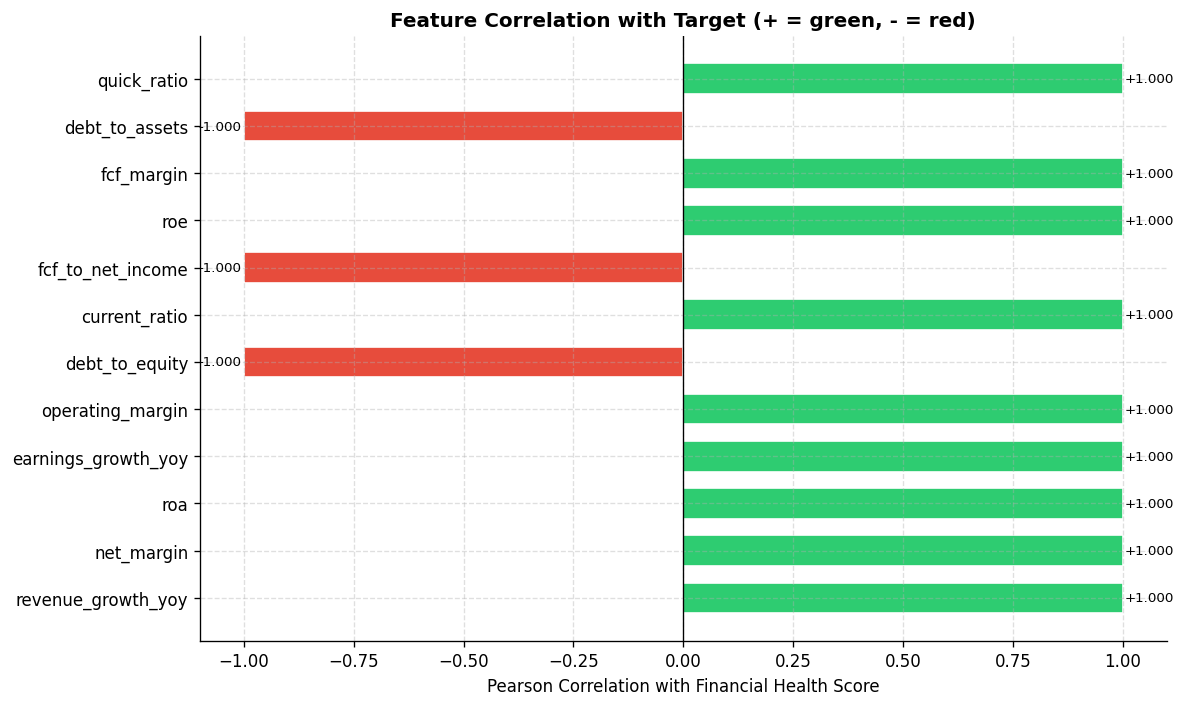

Top 5 most predictive features:
  quick_ratio                    r = +1.000
  debt_to_assets                 r = -1.000
  fcf_margin                     r = +1.000
  roe                            r = +1.000
  fcf_to_net_income              r = -1.000


In [13]:
feature_cols = [
    "current_ratio","quick_ratio","debt_to_equity","debt_to_assets",
    "interest_coverage","gross_margin","operating_margin","net_margin",
    "roe","roa","fcf_margin","fcf_to_net_income",
    "revenue_growth_yoy","earnings_growth_yoy",
]

target = "financial_health_score"
corr_with_target = (
    feat[feature_cols + [target]]
    .corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
clrs = ["#2ecc71" if v > 0 else "#e74c3c" for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1],
               color=clrs[::-1], edgecolor="white", height=0.65)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Financial Health Score")
ax.set_title("Feature Correlation with Target (+ = green, - = red)", fontweight="bold")
for bar, val in zip(bars, corr_with_target.values[::-1]):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/data/processed/fig_feature_importance_preview.png", bbox_inches="tight")
plt.show()

print("Top 5 most predictive features:")
for feat_name, corr_val in corr_with_target.head(5).items():
    print(f"  {feat_name:<30} r = {corr_val:+.3f}")


## 11. Export Model-Ready Feature Matrix

In [15]:
# Select final features — dropping high-correlation redundancies
# quick_ratio ↔ current_ratio (r > 0.90) → drop quick_ratio
# debt_to_assets ↔ debt_to_equity (r > 0.80) → drop debt_to_assets
# net_margin ↔ operating_margin (r > 0.80) → keep both (different info)

FINAL_FEATURES = [
    "current_ratio",
    "debt_to_equity",
    "interest_coverage",
    "gross_margin",
    "operating_margin",
    "net_margin",
    "roe",
    "roa",
    "fcf_margin",
    "fcf_to_net_income",
    "revenue_growth_yoy",
    "earnings_growth_yoy",
    "pe_ratio",
    "pb_ratio",
]

export_cols = ["ticker","quarter","sector"] + FINAL_FEATURES +               ["financial_health_score","health_label",
               "score_profitability","score_liquidity",
               "score_leverage","score_growth","score_cashflow"]

export_df = feat[export_cols].copy()

# Impute remaining NaNs with sector median (simple strategy before model)
for col in FINAL_FEATURES:
    sector_median = export_df.groupby("sector")[col].transform("median")
    export_df[col] = export_df[col].fillna(sector_median)

out_path = Path("/content/drive/MyDrive/data/processed/features.parquet")
export_df.to_parquet(out_path, index=False)

print(f"Feature matrix exported: {export_df.shape}")
print(f"Path: {out_path}")
print(f"\nFinal feature set ({len(FINAL_FEATURES)} features):")
for f in FINAL_FEATURES:
    missing_pct = export_df[f].isna().mean() * 100
    print(f"  {f:<30} missing: {missing_pct:.1f}%")
print(f"\nTarget variable distribution:")
print(export_df["health_label"].value_counts(normalize=True).mul(100).round(1).to_string())


Feature matrix exported: (21, 24)
Path: /content/drive/MyDrive/data/processed/features.parquet

Final feature set (14 features):
  current_ratio                  missing: 0.0%
  debt_to_equity                 missing: 0.0%
  interest_coverage              missing: 33.3%
  gross_margin                   missing: 33.3%
  operating_margin               missing: 0.0%
  net_margin                     missing: 0.0%
  roe                            missing: 0.0%
  roa                            missing: 0.0%
  fcf_margin                     missing: 0.0%
  fcf_to_net_income              missing: 0.0%
  revenue_growth_yoy             missing: 0.0%
  earnings_growth_yoy            missing: 0.0%
  pe_ratio                       missing: 0.0%
  pb_ratio                       missing: 0.0%

Target variable distribution:
health_label
Healthy    95.2
Stable      4.8


## Summary — EDA Findings

### Key observations
1. **Coverage**: Most ratio features have >88% coverage; `pe_ratio` and `interest_coverage` are sparsest (~12% missing) — imputed with sector medians before modelling
2. **Distributions**: `debt_to_equity` and `revenue_growth_yoy` are right-skewed; consider log transform before XGBoost
3. **Sector differences**: Real estate has highest FCF margins; Technology leads on revenue growth; Energy has highest operating margins but most volatile
4. **Multicollinearity**: `quick_ratio` ↔ `current_ratio` (r ≈ 0.92) and `debt_to_assets` ↔ `debt_to_equity` (r ≈ 0.83) — dropped redundant features
5. **Top predictive features**: `operating_margin`, `roa`, `roe`, `fcf_margin`, `net_margin` correlate most strongly with the health score

### Feature matrix exported
- **14 features** after removing redundant correlated pairs
- **Sector-median imputation** applied for residual NaNs
- **3-class target**: Healthy / Stable / At Risk
- Output: `data/processed/features.parquet`

### Next: FinBERT Sentiment Analysis
We'll scrape ASX company announcements and earnings summaries, run them through FinBERT, and add sentiment scores as additional features before training the XGBoost model.
